<a href="https://colab.research.google.com/github/1kilele/Data-science-/blob/main/BudgetFood/BudgetFood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("BudgetFood.csv")
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns")
df['exp_per_capita']=df['totexp']/df['size']
df['log_totexp']=np.log(df['totexp'])
print(df.columns.tolist())


The dataset has 23972 rows and 7 columns
['rownames', 'wfood', 'totexp', 'age', 'size', 'town', 'sex', 'exp_per_capita', 'log_totexp']


In [ ]:
print("The town value counts is:",df["town"].value_counts())


The town value counts is: town
4    9883
3    4362
2    3986
1    2903
5    2838
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
X=df[['log_totexp','age','size','town','exp_per_capita']]
y=df['wfood']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=RandomForestRegressor(n_estimators=100,max_depth=3,random_state=42,min_samples_leaf=5)
model.fit(X_train,y_train)


prediction=model.predict(X_test)
import numpy as np
mae=mean_absolute_error(y_test,prediction)
rmse=np.sqrt(mean_squared_error(y_test,prediction))
r2=r2_score(y_test,prediction)

print(f"Mean Absolute Error(MAE):{mae:.4f}")
print(f"Root Mean Squared Error(RMSE):{rmse:.4f}")
print(f"R-squared score:{r2:.4f}")










Mean Absolute Error(MAE):0.1005
Root Mean Squared Error(RMSE):0.1309
R-squared score:0.3836


In [ ]:
feature_importances=model.feature_importances_
Feature_Importances=pd.Series(feature_importances,index=X.columns)
print(Feature_Importances.sort_values(ascending=False))

exp_per_capita    0.756541
log_totexp        0.223576
age               0.018805
size              0.000888
town              0.000189
dtype: float64


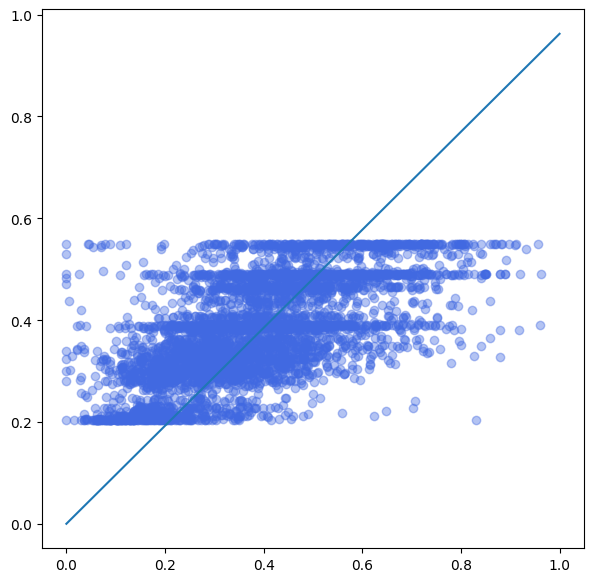

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,7))
plt.scatter(y_test,prediction,color='royalblue',alpha=0.4,label="Households")

perfect_line_range=[y_test.min(),y_test.max()]
plt.plot(perfect)
